In [ ]:
!pip install scanpy squidpy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Using CPU")

Using CPU


In [4]:
##Working with google colab
import os
import sys

os.chdir("/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Hadmard_Attention")
cwd = os.getcwd()
print(cwd)
sys.path.append("../../")

/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Hadmard_Attention


In [5]:
import scanpy as sc
import squidpy as sq
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np

import matplotlib.pyplot as plt

In [6]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'DejaVu Sans'

pltkw = dict(bbox_inches='tight', transparent=True)

In [7]:
import HadmardAttention as HA

In [8]:
import importlib
import HadmardAttention.tools
import HadmardAttention.model

## Data

Founsation Models

In [19]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/UNI_adata.h5ad")

In [22]:
ad = adata.copy()

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/hoptimus_adata.h5ad")

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/FMs_3/virchow_adata.h5ad")

Noise

In [ ]:
adata = sc.read_h5ad("../../../Data/Breast_Cancer/ann_data.h5ad")

In [ ]:
rng = np.random.default_rng(42)
ad = adata.copy()
ad.obsm["morpho"] = rng.standard_normal((167780, 500))

In [ ]:
adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho'] - np.min(ad.obsm['morpho'])

Preparing Dataset

In [ ]:
importlib.reload(HA.dataset)
importlib.reload(HA.model)
importlib.reload(HA)

<module 'HadmardAttention' from '/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Hadmard_Attention/../../HadmardAttention/__init__.py'>

In [13]:
adata = HA.prep_adatas(adata, norm=True, log1p=True)
dataset = HA.make_dataset(adata, sparse_graph=True)

/content/drive/MyDrive/Thesis/Projects/Master_Thesis/Notebooks/Hadmard_Attention/../../HadmardAttention/dataset.py:37: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.


In [ ]:
print('Expression', dataset[0][0].shape)
print('Morpho_Embedding', dataset[0][1].shape)
print('Neighborhood_Graph', dataset[0][2].shape)

Expression torch.Size([167780, 313])
Morpho_Embedding torch.Size([167780, 500])
Neighborhood_Graph torch.Size([2, 1342240])


In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()

## Reconstruction Error

In [ ]:
model_type = 0

HA.set_random_seed(42)
model = HA.model.Steamboat(features=len(adata.var_names.tolist()), morpho_features=adata.obsm['p_Morpho_Embedding'].shape[1], n_heads=32, model_type=model_type, n_scales=2)
model = model.to(device)


### virchow

In [ ]:
if device == 'cpu':
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_virchow_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_virchow_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))

In [ ]:
## UNI
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    res = model(adj_list, x, m, x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  0
tensor(0.0990)


In [ ]:
## UNI
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    res = model(adj_list, x, m, x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  5
tensor(0.0987)


### UNI

In [ ]:
if device == 'cpu':
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_UNI_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_UNI_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))

In [ ]:
## UNI
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    res = model(adj_list, x, m, x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  0
tensor(0.0990)


In [ ]:
## UNI
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    res = model(adj_list, x, m, x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  5
tensor(0.0987)


### h_optimus

In [ ]:
if device == 'cpu':
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_hoptimus_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_hoptimus_{model_type}.pth',weights_only=True))

In [ ]:
## h_optimus
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    masked_x = model.masking(x, 0)

    res = model(adj_list, x, m, masked_x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  0
tensor(0.1018, device='cuda:0')


In [ ]:
## h_optimus
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    masked_x = model.masking(x, 0)

    res = model(adj_list, x, m, masked_x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  5
tensor(0.1003, device='cuda:0')


### NOISE

In [ ]:
if device == 'cpu':
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_NOISE_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_NOISE_{model_type}.pth',weights_only=True))

In [ ]:
## NOISE
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    masked_x = model.masking(x, 0)

    res = model(adj_list, x, m, masked_x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  0
tensor(0.1237, device='cuda:0')


In [ ]:
## NOISE
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    masked_x = model.masking(x, 0)

    res = model(adj_list, x, m, masked_x, m, get_details=False)
    loss = criterion(res, x)
    print(loss)

model_type:  5
tensor(0.1178, device='cuda:0')


## Gene Vector Analysis

### UNI

In [14]:
model_type = 0

HA.set_random_seed(42)
model = HA.model.Steamboat(features=len(adata.var_names.tolist()), morpho_features=adata.obsm['p_Morpho_Embedding'].shape[1], n_heads=32, model_type=model_type, n_scales=2)
model = model.to(device)


In [15]:
if device == 'cpu':
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_UNI_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_UNI_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))

In [16]:
## UNI
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    res_0, det_0 = model(adj_list, x, m, x, m, get_details=True)

model_type:  0


In [17]:
det_0.keys()

dict_keys(['attn', 'attnp', 'attnm'])

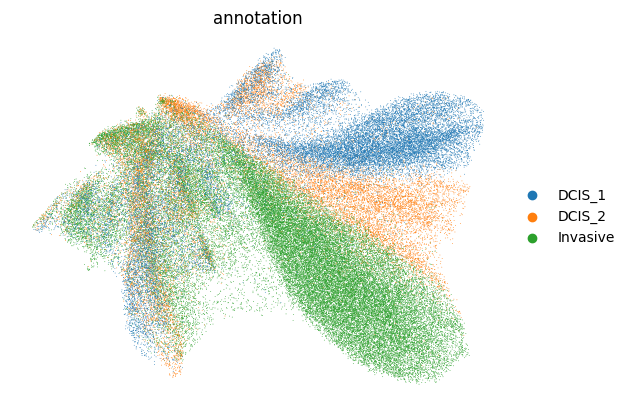

In [18]:
mask = adata.obs['annotation'].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
ad2 = ad[mask]
# Build neighbors using embedding space
sc.pp.neighbors(ad2, use_rep='X')

# Compute UMAPac
sc.tl.umap(ad2)

# Plot
sc.pl.umap(ad2, color="annotation", frameon=False)

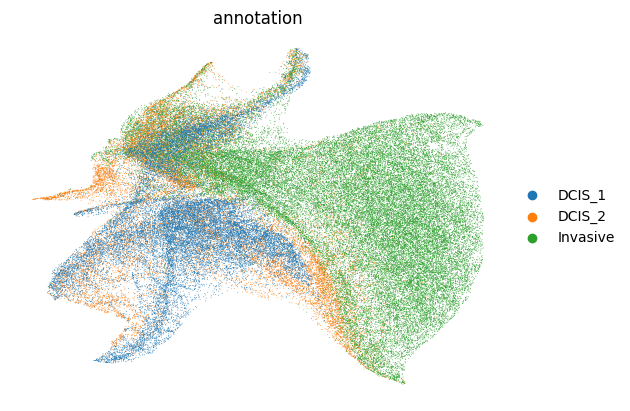

In [33]:
ad.obsm['local emb'] = det_0['attnm'][1].numpy()
ad2 = ad[mask]
# Build neighbors using embedding space
sc.pp.neighbors(ad2, use_rep='local emb')

# Compute UMAPac
sc.tl.umap(ad2)

# Plot
sc.pl.umap(ad2, color="annotation", frameon=False)

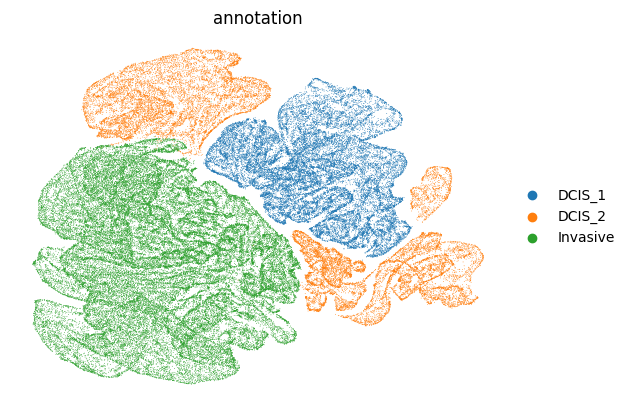

In [ ]:
mask = ad.obs['annotation'].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
ad2 = ad[mask]
# Build neighbors using embedding space
sc.pp.neighbors(ad2, use_rep='p_Morpho_Embedding')

# Compute UMAPac
sc.tl.umap(ad2)

# Plot
sc.pl.umap(ad2, color="annotation", frameon=False)

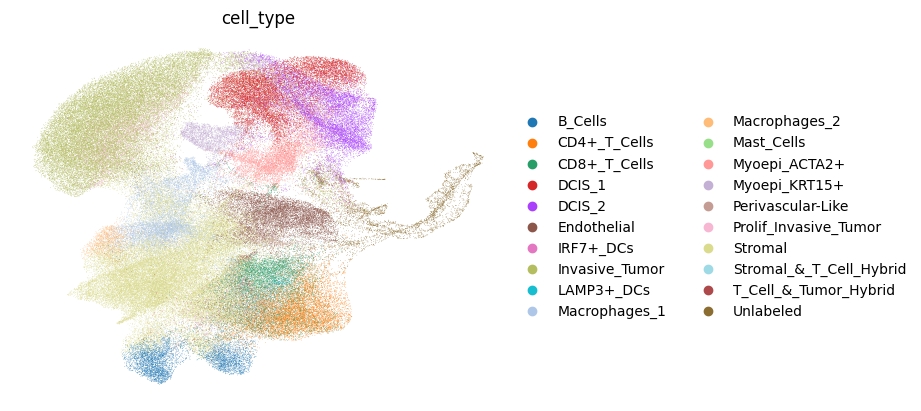

In [ ]:
ad.obsm['emb'] = det_0['attn'].numpy()
# Build neighbors using embedding space
sc.pp.neighbors(ad, use_rep='emb')

# Compute UMAPac
sc.tl.umap(ad)

# Plot
sc.pl.umap(ad, color="cell_type", frameon=False)

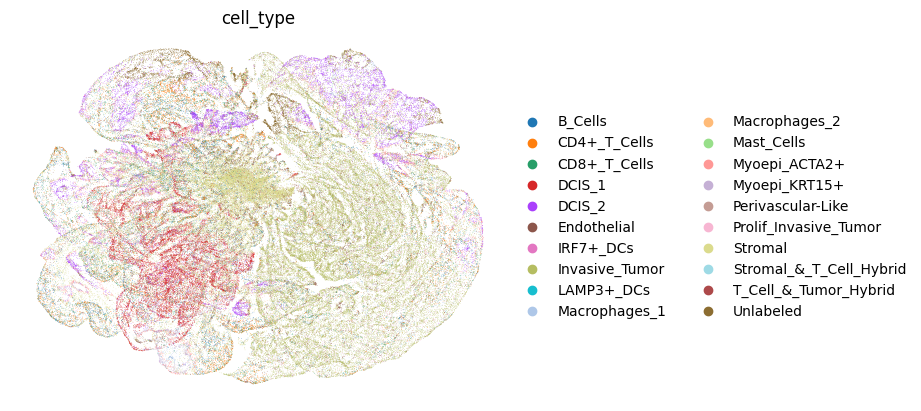

In [ ]:
ad = adata.copy()
# Build neighbors using embedding space
sc.pp.neighbors(ad, use_rep='p_Morpho_Embedding')

# Compute UMAPac
sc.tl.umap(ad)

# Plot
sc.pl.umap(ad, color="cell_type", frameon=False)

### NOISE

In [ ]:
model_type = 0

HA.set_random_seed(42)
model = HA.model.Steamboat(features=len(adata.var_names.tolist()), morpho_features=adata.obsm['p_Morpho_Embedding'].shape[1], n_heads=32, model_type=model_type, n_scales=2)
model = model.to(device)


In [ ]:
if device == 'cpu':
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_NOISE_{model_type}.pth',weights_only=True, map_location=torch.device('cpu')))
else:
  model.load_state_dict(torch.load(f'saved_models/breast_cancer_32_NOISE_{model_type}.pth',weights_only=True))

In [ ]:
## NOISE
loader = DataLoader(dataset, batch_size=1, shuffle=False)
criterion = nn.MSELoss(reduction='mean')

res_0 = 0
det_0 = {}
with torch.no_grad():
  for x, m, adj_list in loader:

    adj_list = adj_list.squeeze(0).to(device)
    x = x.squeeze(0).to(device)
    m = m.squeeze(0).to(device)

    masked_x = model.masking(x, 0)

    res_0, det_0 = model(adj_list, x, m, masked_x, m, get_details=True)

## ROI Segmentation

## Cell Type Clustering

## Embedding Similarity

In [ ]:
mask1 = (ad.obs['annotation'] == "DCIS_1") & (ad.obs['cell_type'] == "T_Cell_&_Tumor_Hybrid")
mask2 = (ad.obs['annotation'] == "DCIS_2") & (ad.obs['cell_type'] == "T_Cell_&_Tumor_Hybrid")
mask3 = (ad.obs['annotation'] == "DCIS_1")  & (ad.obs['cell_type'] == "Invasive_Tumor")
mask4 = (ad.obs['annotation'] == "DCIS_2")  & (ad.obs['cell_type'] == "Invasive_Tumor")

In [ ]:
X = adata.X.toarray()

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix0 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

In [ ]:
X = adata.obsm['p_Morpho_Embedding']

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix1 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

In [ ]:
X = det_0['attn']

# group-level gene expression vectors (mean across cells)
g1 = X[mask1].mean(axis=0)
g2 = X[mask2].mean(axis=0)
g3 = X[mask3].mean(axis=0)
g4 = X[mask4].mean(axis=0)


group_matrix2 = pd.DataFrame({
    "DCIS_1 & T_cell": g1,
    "DCIS_2 & T_cell": g2,
    "DCIS_1 & Tumor": g3,
    "DCIS_2 & Tumor": g4
})

/tmp/ipykernel_11150/2415704170.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  g1 = X[mask1].mean(axis=0)
/tmp/ipykernel_11150/2415704170.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  g2 = X[mask2].mean(axis=0)
/tmp/ipykernel_11150/2415704170.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  g3 = X[mask3].mean(axis=0)
/tmp/ipykernel_11150/2415704170.py:7: FutureWarning: Series.__getitem__ treating keys as positions is d

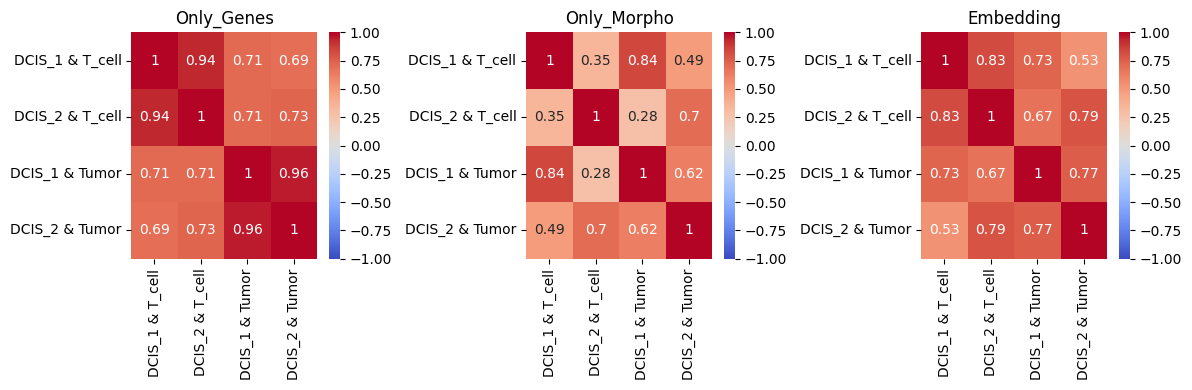

In [ ]:
import seaborn as sns

corr1 = group_matrix0.corr()
corr2 = group_matrix1.corr()
corr3 = group_matrix2.corr()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.heatmap(corr1, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Only_Genes")

sns.heatmap(corr2, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Only_Morpho")

sns.heatmap(corr3, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Embedding")

plt.tight_layout()
plt.show()